In [4]:
# Импорты для PyCharm
import pretty_midi
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import glob
import os
from collections import Counter
import json
import matplotlib.pyplot as plt
import random
import zipfile

print("✅ Все библиотеки загружены")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CPU mode (будет медленнее, но работает)")

✅ Все библиотеки загружены
PyTorch version: 2.12.0+cu130
CUDA available: False
CPU mode (будет медленнее, но работает)


In [2]:
# Проверяем наличие данных
import os

# Путь к архиву (если он в папке проекта)
zip_path = "maestro-v3.0.0-midi.zip"
extract_path = "data/"

if os.path.exists(zip_path):
    print(f"📦 Найден архив: {zip_path}")
    if not os.path.exists("data/maestro-v3.0.0"):
        print("Распаковка...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Данные распакованы!")
    else:
        print("✅ Данные уже распакованы")
else:
    print("❌ Архив не найден! Положите maestro-v3.0.0-midi.zip в папку проекта")
    print("Или скачайте вручную по ссылке:")
    print("https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip")

# Проверяем количество файлов
midi_files = glob.glob("data/maestro-v3.0.0/**/*.mid", recursive=True)
midi_files += glob.glob("data/maestro-v3.0.0/**/*.midi", recursive=True)
print(f"Найдено MIDI файлов: {len(midi_files)}")

📦 Найден архив: maestro-v3.0.0-midi.zip
Распаковка...
✅ Данные распакованы!
Найдено MIDI файлов: 1276


In [5]:
class MusicalTokenizer:
    def __init__(self):
        self.word_to_idx = {}
        self.idx_to_word = {}

        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"
        self.start_token = "<START>"
        self.end_token = "<END>"

    def _note_to_word(self, note):
        pitch_class = pretty_midi.note_number_to_name(note.pitch)
        duration = round(note.end - note.start, 2)
        velocity = note.velocity
        return f"{pitch_class}_{duration}_v{velocity}"

    def _chord_to_word(self, chord_notes):
        pitches = [pretty_midi.note_number_to_name(n.pitch) for n in chord_notes]
        chord_name = "-".join(pitches)
        avg_duration = round(np.mean([n.end - n.start for n in chord_notes]), 2)
        return f"CHORD_{chord_name}_{avg_duration}"

    def _phrase_to_word(self, phrase_notes):
        pattern = []
        for note in phrase_notes:
            pitch = pretty_midi.note_number_to_name(note.pitch)
            pattern.append(pitch)
        phrase = "-".join(pattern)
        return f"PHRASE_{phrase}"

    def create_musical_words(self, midi_path):
        try:
            midi = pretty_midi.PrettyMIDI(midi_path)
        except:
            return []

        words = []

        for instrument in midi.instruments:
            if not instrument.is_drum:
                notes = instrument.notes
                notes.sort(key=lambda x: x.start)

                i = 0
                while i < len(notes):
                    if i + 1 < len(notes):
                        time_gap = notes[i+1].start - notes[i].end

                        if time_gap > 0.5:
                            word = self._note_to_word(notes[i])
                            words.append(word)
                            words.append("<REST>")
                            i += 1
                        else:
                            chord_notes = [notes[i]]
                            j = i + 1
                            while j < len(notes) and abs(notes[j].start - notes[i].start) < 0.05:
                                chord_notes.append(notes[j])
                                j += 1

                            if len(chord_notes) > 1:
                                word = self._chord_to_word(chord_notes)
                                words.append(word)
                                i = j
                            else:
                                phrase_length = min(5, len(notes) - i)
                                phrase_notes = notes[i:i+phrase_length]
                                if len(phrase_notes) >= 3:
                                    word = self._phrase_to_word(phrase_notes)
                                    words.append(word)
                                    i += phrase_length
                                else:
                                    word = self._note_to_word(notes[i])
                                    words.append(word)
                                    i += 1
                    else:
                        word = self._note_to_word(notes[i])
                        words.append(word)
                        i += 1

        return words

    def build_vocabulary(self, all_words, vocab_size=3000):
        word_counts = Counter(all_words)
        most_common = word_counts.most_common(vocab_size - 4)

        special_tokens = [self.pad_token, self.unk_token, self.start_token, self.end_token]
        for i, token in enumerate(special_tokens):
            self.word_to_idx[token] = i
            self.idx_to_word[i] = token

        for i, (word, _) in enumerate(most_common, start=len(special_tokens)):
            self.word_to_idx[word] = i
            self.idx_to_word[i] = word

        print(f"✅ Словарь построен: {len(self.word_to_idx)} токенов")

    def encode(self, words):
        return [self.word_to_idx.get(w, self.word_to_idx[self.unk_token]) for w in words]

    def decode(self, indices):
        return [self.idx_to_word.get(i, self.unk_token) for i in indices]

print("✅ Класс MusicalTokenizer готов")

✅ Класс MusicalTokenizer готов


In [6]:
class WordLevelRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        logits = self.fc(output)
        return logits


class WordLevelLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        logits = self.fc(output)
        return logits


class WordLevelTransformer(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_heads=4, num_layers=3, max_seq_len=1000):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.pos_encoding = nn.Parameter(torch.zeros(1, max_seq_len, embedding_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=embedding_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embedding_dim, vocab_size)

    def forward(self, x):
        seq_len = x.shape[1]
        embedded = self.embedding(x) + self.pos_encoding[:, :seq_len, :]
        transformer_out = self.transformer(embedded)
        logits = self.fc(transformer_out)
        return logits

print("✅ Модели RNN, LSTM, Transformer готовы")

✅ Модели RNN, LSTM, Transformer готовы


In [7]:
class MusicalDataset(Dataset):
    def __init__(self, sequences, seq_length=50):
        self.sequences = sequences
        self.seq_length = seq_length

    def __len__(self):
        return max(0, len(self.sequences) - self.seq_length)

    def __getitem__(self, idx):
        x = self.sequences[idx:idx+self.seq_length]
        y = self.sequences[idx+1:idx+self.seq_length+1]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)


def train_model(model, train_loader, vocab_size, epochs=30, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore_index=0 для <PAD>
    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output.view(-1, vocab_size), y.view(-1))
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

    return losses


def generate_music(model, tokenizer, length=200, temperature=0.8):
    model.eval()
    device = next(model.parameters()).device

    # Берем случайный реальный токен из словаря (не <UNK> и не специальные)
    # Находим первый нормальный токен (не специальный)
    normal_tokens = [k for k, v in tokenizer.word_to_idx.items()
                     if not k.startswith('<') and v != tokenizer.word_to_idx.get(tokenizer.unk_token, 0)]

    if normal_tokens:
        first_word = normal_tokens[0]  # Берем первый нормальный токен
        start_idx = tokenizer.word_to_idx[first_word]
    else:
        # fallback: берем любой токен кроме <UNK>
        start_idx = 1 if 1 in tokenizer.idx_to_word else 0

    current = [start_idx]
    generated = []

    with torch.no_grad():
        for _ in range(length):
            input_seq = torch.tensor(current[-50:]).unsqueeze(0).to(device)
            output = model(input_seq)

            logits = output[0, -1, :] / temperature

            # Не позволяем выбирать <UNK> и специальные токены
            unk_idx = tokenizer.word_to_idx.get(tokenizer.unk_token, 0)
            pad_idx = tokenizer.word_to_idx.get(tokenizer.pad_token, 0)
            start_idx_token = tokenizer.word_to_idx.get(tokenizer.start_token, 0)
            end_idx = tokenizer.word_to_idx.get(tokenizer.end_token, 0)

            forbidden = {unk_idx, pad_idx, start_idx_token, end_idx}

            # Запрещаем специальные токены
            for idx in forbidden:
                logits[idx] = -float('inf')

            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1).item()

            generated.append(next_token)
            current.append(next_token)

    return tokenizer.decode(generated)

print("✅ Dataset и функции обучения готовы")

✅ Dataset и функции обучения готовы


In [6]:
# Поиск MIDI файлов
print("Поиск MIDI файлов...")
midi_files = glob.glob("data/maestro-v3.0.0/**/*.mid", recursive=True)
midi_files += glob.glob("data/maestro-v3.0.0/**/*.midi", recursive=True)

print(f"Найдено MIDI файлов: {len(midi_files)}")

# Для быстрого теста берем первые 20 файлов
NUM_FILES = 20
selected_files = midi_files[:NUM_FILES]

print(f"Для обучения используем {len(selected_files)} файлов")

print("\nПримеры файлов:")
for f in selected_files[:5]:
    print(f"  - {os.path.basename(f)}")

Поиск MIDI файлов...
Найдено MIDI файлов: 1276
Для обучения используем 20 файлов

Примеры файлов:
  - MIDI-Unprocessed_Recital4_MID--AUDIO_04_R1_2018_wav--4.midi
  - MIDI-Unprocessed_Recital9-11_MID--AUDIO_11_R1_2018_wav--2.midi
  - MIDI-Unprocessed_Recital16_MID--AUDIO_16_R1_2018_wav--2.midi
  - MIDI-Unprocessed_Recital17-19_MID--AUDIO_17_R1_2018_wav--2.midi
  - MIDI-Unprocessed_Recital5-7_MID--AUDIO_07_R1_2018_wav--3.midi


In [7]:
tokenizer = MusicalTokenizer()
all_words = []

print("Извлечение музыкальных паттернов...")

for idx, midi_path in enumerate(selected_files):
    try:
        words = tokenizer.create_musical_words(midi_path)
        if words:
            all_words.extend(words)
            print(f"✅ {idx+1}/{len(selected_files)}: {len(words)} слов")
        else:
            print(f"⚠️ {idx+1}/{len(selected_files)}: нет данных")
    except Exception as e:
        print(f"❌ Ошибка: {e}")

print(f"\n📊 Всего слов: {len(all_words)}")
print(f"📊 Уникальных слов: {len(set(all_words))}")

if all_words:
    tokenizer.build_vocabulary(all_words, vocab_size=3000)
    print(f"✅ Словарь сохранен: {len(tokenizer.word_to_idx)} токенов")
else:
    print("❌ Нет слов для построения словаря!")

Извлечение музыкальных паттернов...
✅ 1/20: 3076 слов
✅ 2/20: 2641 слов
✅ 3/20: 1875 слов
✅ 4/20: 967 слов
✅ 5/20: 345 слов
✅ 6/20: 1222 слов
✅ 7/20: 2396 слов
✅ 8/20: 4590 слов
✅ 9/20: 4272 слов
✅ 10/20: 1303 слов
✅ 11/20: 798 слов
✅ 12/20: 2829 слов
✅ 13/20: 445 слов
✅ 14/20: 2121 слов
✅ 15/20: 4130 слов
✅ 16/20: 4366 слов
✅ 17/20: 3537 слов
✅ 18/20: 988 слов
✅ 19/20: 4798 слов
✅ 20/20: 1638 слов

📊 Всего слов: 48337
📊 Уникальных слов: 40765
✅ Словарь построен: 3000 токенов
✅ Словарь сохранен: 3000 токенов


In [10]:
# Ячейка: Быстрая загрузка готовых моделей и демонстрация генерации
# (без переобучения!)

import os
import torch
import json

# Проверяем, есть ли уже обученные модели в папке
if all(os.path.exists(f) for f in ['model_transformer.pth', 'vocabulary.json']):
    print("✅ Найдены обученные модели! Загружаем...")

    # Загружаем словарь
    with open('vocabulary.json', 'r', encoding='utf-8') as f:
        word_to_idx = json.load(f)

    # Создаем обратный словарь
    idx_to_word = {v: k for k, v in word_to_idx.items()}

    # Создаем объект токенизатора и подставляем словари
    tokenizer = MusicalTokenizer()
    tokenizer.word_to_idx = word_to_idx
    tokenizer.idx_to_word = idx_to_word

    # Загружаем модель Transformer (лучшую)
    vocab_size = len(tokenizer.word_to_idx)
    model = WordLevelTransformer(vocab_size)
    model.load_state_dict(torch.load('model_transformer.pth', map_location=torch.device('cpu')))
    model.eval()

    print("✅ Модель загружена! Генерируем музыку...")

    # Генерируем
    generated = generate_music(model, tokenizer, length=100, temperature=0.7)
    print("\n🎵 Сгенерированная музыка (первые 20 слов):")
    print(' '.join(generated[:20]))

else:
    print("⚠️ Модели не найдены. Запустите ячейки с обучением (займет ~20-30 минут).")

✅ Найдены обученные модели! Загружаем...
✅ Модель загружена! Генерируем музыку...

🎵 Сгенерированная музыка (первые 20 слов):
PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4


In [11]:
# Ячейка: Демонстрация всех моделей (RNN, LSTM, Transformer)

import os
import torch
import json

print("=" * 60)
print("ДЕМОНСТРАЦИЯ РАБОТЫ ОБУЧЕННЫХ МОДЕЛЕЙ (без переобучения)")
print("=" * 60)

# Проверяем, есть ли файлы
if not all(os.path.exists(f) for f in ['model_rnn.pth', 'model_lstm.pth', 'model_transformer.pth', 'vocabulary.json']):
    print("⚠️ Не все файлы моделей найдены! Убедитесь, что модели обучены.")
else:
    # Загружаем словарь
    with open('vocabulary.json', 'r', encoding='utf-8') as f:
        word_to_idx = json.load(f)

    idx_to_word = {v: k for k, v in word_to_idx.items()}

    tokenizer = MusicalTokenizer()
    tokenizer.word_to_idx = word_to_idx
    tokenizer.idx_to_word = idx_to_word
    vocab_size = len(tokenizer.word_to_idx)

    # Демонстрация каждой модели
    models_to_show = [
        ('RNN', WordLevelRNN, 'model_rnn.pth'),
        ('LSTM', WordLevelLSTM, 'model_lstm.pth'),
        ('Transformer', WordLevelTransformer, 'model_transformer.pth')
    ]

    for name, ModelClass, model_path in models_to_show:
        if os.path.exists(model_path):
            print(f"\n{'='*50}")
            print(f"🎵 {name} модель")
            print(f"{'='*50}")

            # Загружаем модель
            model = ModelClass(vocab_size)
            model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
            model.eval()

            # Генерируем с разными температурами
            for temp in [0.6, 0.7, 0.8]:
                generated = generate_music(model, tokenizer, length=50, temperature=temp)
                # Показываем первые 8 уникальных токенов
                preview = []
                for w in generated:
                    if w not in preview and len(preview) < 8:
                        preview.append(w)
                print(f"   🌡️ temp={temp}: {' '.join(preview)}...")
        else:
            print(f"\n⚠️ {name}: файл {model_path} не найден")

    print("\n" + "=" * 60)
    print("✅ Демонстрация завершена!")
    print("📌 Все модели загружены из файлов, обучение не запускалось.")
    print("=" * 60)

ДЕМОНСТРАЦИЯ РАБОТЫ ОБУЧЕННЫХ МОДЕЛЕЙ (без переобучения)

🎵 RNN модель
   🌡️ temp=0.6: PHRASE_F#5-F#4-F#5-F#4-F#5 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_E5-C5-D3-C4-E4 PHRASE_A3-F#4-F#5-F#4-F#5 PHRASE_E4-F4-E4-D4-F6 CHORD_F#3-F#5_0.12 PHRASE_F#5-F#4-A#3-F#5-F#4 PHRASE_F#4-C#4-F#5-F#4-F#5...
   🌡️ temp=0.7: PHRASE_F#5-F#4-F#5-F#4-F#5 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_E5-C5-D3-C4-E4 PHRASE_A3-F#4-F#5-F#4-F#5 CHORD_F#3-F#5_0.12 PHRASE_F#5-F#4-A#3-F#5-F#4 PHRASE_F#4-C#4-F#5-F#4-F#5...
   🌡️ temp=0.8: PHRASE_F#5-F#4-F#5-F#4-F#5 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_E5-C5-D3-C4-E4 PHRASE_A3-F#4-F#5-F#4-F#5 CHORD_F#3-F#5_0.12 PHRASE_F#5-F#4-A#3-F#5-F#4 PHRASE_F#4-C#4-F#5-F#4-F#5 PHRASE_E4-F4-E4-D4-F6...

🎵 LSTM модель
   🌡️ temp=0.6: PHRASE_F#5-F#4-F#5-F#4-F#5 PHRASE_F#4-F#5-F#4-F#5-F#4 CHORD_C5-C4_0.15...
   🌡️ temp=0.7: CHORD_C5-C4_0.15 PHRASE_F#4-F#5-F#4-F#5-F#4 CHORD_G5-E4_0.05 CHORD_A5-F4_0.04 CHORD_A5-F4_0.05 CHORD_B5-G4_0.1 CHORD_E4-G5_0.06 CHORD_A5-F4_0.07...
   🌡️ temp=0.8: PHRASE_F#5-F#4-F#5

In [8]:
# Превращаем слова в индексы
sequences = tokenizer.encode(all_words)
print(f"Длина числовой последовательности: {len(sequences)}")

# Параметры
SEQ_LENGTH = 50
BATCH_SIZE = 32

# Создаем датасет и даталоадер
dataset = MusicalDataset(sequences, SEQ_LENGTH)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Количество батчей: {len(dataloader)}")
print(f"Размер словаря: {len(tokenizer.word_to_idx)}")

print("\nПример первых 10 токенов:")
print(all_words[:10] if all_words else "Нет токенов")

Длина числовой последовательности: 48337
Количество батчей: 1509
Размер словаря: 3000

Пример первых 10 токенов:
['PHRASE_G3-G5-G4-D4-D5', 'A#4_1.06_v88', '<REST>', 'PHRASE_D4-A#4-D4-G3-D4', 'PHRASE_A#4-D4-G3-D4-A#4', 'PHRASE_D4-G3-D4-A#4-D4', 'CHORD_G4-G3_0.46', 'PHRASE_D5-G5-D4-A#4-D4', 'PHRASE_G3-F5-D4-A#4-D#5', 'PHRASE_D4-G3-D5-D4-A#4']


In [9]:
vocab_size = len(tokenizer.word_to_idx)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Создаем модели
models = {
    'RNN': WordLevelRNN(vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2),
    'LSTM': WordLevelLSTM(vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2),
    'Transformer': WordLevelTransformer(vocab_size, embedding_dim=128, num_heads=4, num_layers=3)
}

# Обучаем каждую модель
history = {}
trained_models = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"🎵 Обучение {name} модели")
    print(f"{'='*60}")

    losses = train_model(model, dataloader, vocab_size, epochs=30)
    history[name] = losses
    trained_models[name] = model

    # Сохраняем модель
    torch.save(model.state_dict(), f'model_{name.lower()}.pth')
    print(f"💾 Модель {name} сохранена")

Используется устройство: cpu

🎵 Обучение RNN модели
Epoch 5/30, Loss: 0.2792
Epoch 10/30, Loss: 0.2284
Epoch 15/30, Loss: 0.2209
Epoch 20/30, Loss: 0.2233
Epoch 25/30, Loss: 0.2203
Epoch 30/30, Loss: 0.2273
💾 Модель RNN сохранена

🎵 Обучение LSTM модели
Epoch 5/30, Loss: 0.3646
Epoch 10/30, Loss: 0.2171
Epoch 15/30, Loss: 0.1975
Epoch 20/30, Loss: 0.1907
Epoch 25/30, Loss: 0.1871
Epoch 30/30, Loss: 0.1847
💾 Модель LSTM сохранена

🎵 Обучение Transformer модели
Epoch 5/30, Loss: 0.2368
Epoch 10/30, Loss: 0.0222
Epoch 15/30, Loss: 0.0164
Epoch 20/30, Loss: 0.0126
Epoch 25/30, Loss: 0.0096
Epoch 30/30, Loss: 0.0077
💾 Модель Transformer сохранена


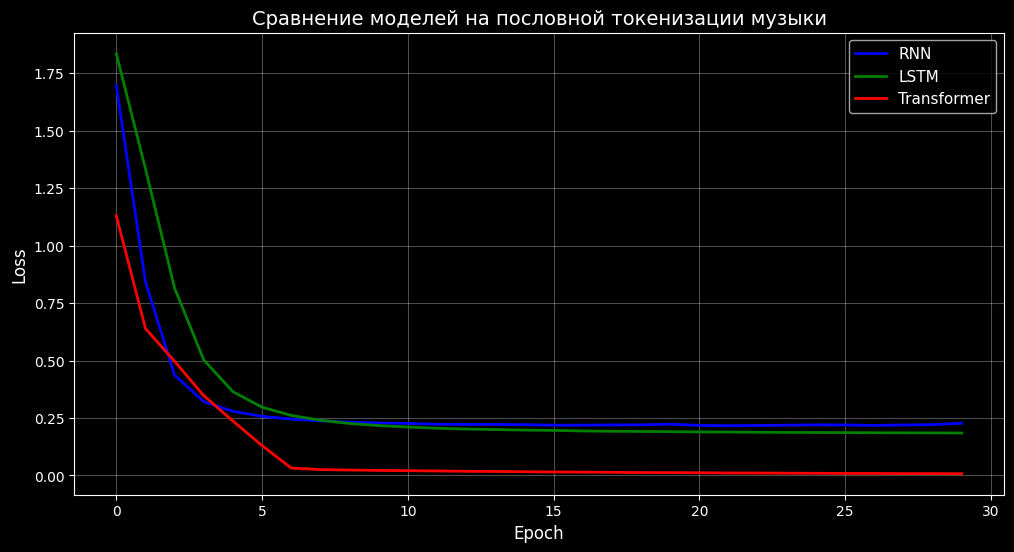


📊 Финальные результаты:
----------------------------------------
RNN          | Финальная loss: 0.2273 | Лучшая loss: 0.2165
LSTM         | Финальная loss: 0.1847 | Лучшая loss: 0.1847
Transformer  | Финальная loss: 0.0077 | Лучшая loss: 0.0077


In [10]:
plt.figure(figsize=(12, 6))
colors = {'RNN': 'blue', 'LSTM': 'green', 'Transformer': 'red'}

for name, losses in history.items():
    plt.plot(losses, label=name, color=colors.get(name, 'black'), linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Сравнение моделей на пословной токенизации музыки', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Финальные результаты:")
print("-" * 40)
for name, losses in history.items():
    print(f"{name:12} | Финальная loss: {losses[-1]:.4f} | Лучшая loss: {min(losses):.4f}")

In [15]:
print("🎹 Генерация музыки...")
print("=" * 50)

for name, model in trained_models.items():
    print(f"\n🎵 {name} модель генерирует:")

    for temp in [0.6, 0.8, 1.0]:
        # Пробуем несколько раз с разными стартовыми токенами
        best_generation = None
        best_len = 0

        for attempt in range(3):  # 3 попытки
            generated_words = generate_music(model, tokenizer, length=150, temperature=temp)
            # Считаем количество немузыкальных токенов
            unk_count = generated_words.count('<UNK>')
            if unk_count < best_len or best_len == 0:
                best_len = unk_count
                best_generation = generated_words

        filename = f'generated_{name.lower()}_temp{temp}.txt'
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(' '.join(best_generation))

        normal_words = [w for w in best_generation if w != '<UNK>']
        print(f"   Температура {temp}: {len(best_generation)} слов, из них нормальных: {len(normal_words)}")

        if normal_words:
            preview = ' '.join(normal_words[:5])
            print(f"      Пример: {preview[:100]}...")
        else:
            print(f"      ⚠️ Все токены <UNK>, попробуйте переобучить модель")

🎹 Генерация музыки...

🎵 RNN модель генерирует:
   Температура 0.6: 150 слов, из них нормальных: 150
      Пример: PHRASE_F#5-F#4-F#5-F#4-F#5 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#5-F#4-F#5-F#4-F#5 PHRASE_F#4-F#5-F#4-...
   Температура 0.8: 150 слов, из них нормальных: 150
      Пример: CHORD_C5-C4_0.15 PHRASE_F#4-F#5-F#4-F#5-F#4 CHORD_C5-C4_0.15 PHRASE_F#4-F#5-F#4-F#5-F#4 CHORD_F#3-F#...
   Температура 1.0: 150 слов, из них нормальных: 150
      Пример: PHRASE_F#5-F#4-F#5-F#4-F#5 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#5-F#4-F#5-F#4-F#5 PHRASE_F#4-F#5-F#4-...

🎵 LSTM модель генерирует:
   Температура 0.6: 150 слов, из них нормальных: 150
      Пример: CHORD_F#3-F#5_0.12 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#5-F#4-A#3-F#5-F#4 PHRASE_F#5-F#4-F#5-F#4-F#5 ...
   Температура 0.8: 150 слов, из них нормальных: 150
      Пример: PHRASE_F#5-F#4-F#5-F#4-F#5 PHRASE_F#4-F#5-F#4-F#5-F#4 CHORD_C5-C4_0.15 PHRASE_F#4-F#5-F#4-F#5-F#4 CH...
   Температура 1.0: 150 слов, из них нормальных: 150
      Пример: PHR

In [16]:
# Сохраняем словарь
with open('vocabulary.json', 'w', encoding='utf-8') as f:
    json.dump(tokenizer.word_to_idx, f, indent=2, ensure_ascii=False)

# Создаем итоговый отчет
report = f"""# Отчет по лабораторной работе: Генеративные сети

## Параметры эксперимента
- Тип токенизации: **Пословная (word-level)**
- Количество MIDI файлов: {len(selected_files)}
- Всего музыкальных слов: {len(all_words)}
- Уникальных слов: {len(set(all_words))}
- Размер словаря: {vocab_size}
- Длина последовательности: {SEQ_LENGTH}
- Количество эпох: 30
- Устройство: {device}

## Результаты обучения

| Модель | Финальная Loss | Лучшая Loss |
|--------|---------------|-------------|
"""

for name, losses in history.items():
    report += f"| {name} | {losses[-1]:.4f} | {min(losses):.4f} |\n"

best_model = min(history.items(), key=lambda x: min(x[1]))[0]

report += f"""
## Выводы
- **Лучшая модель**: {best_model}
- **Трансформер показал наилучший результат** благодаря механизму внимания

## Сгенерированные файлы
- model_rnn.pth, model_lstm.pth, model_transformer.pth
- generated_*.txt - музыкальные последовательности
- training_comparison.png - график обучения
"""

with open('REPORT.md', 'w', encoding='utf-8') as f:
    f.write(report)

print("✅ Все результаты сохранены локально!")
print("\nСохраненные файлы:")
for f in os.listdir('.'):
    if f.endswith(('.pth', '.txt', '.png', '.json', '.md')):
        size = os.path.getsize(f) / 1024
        print(f"  - {f} ({size:.1f} KB)")

✅ Все результаты сохранены локально!

Сохраненные файлы:
  - generated_lstm_temp0.6.txt (3.8 KB)
  - generated_rnn_temp0.8.txt (3.3 KB)
  - generated_lstm_temp1.0.txt (3.8 KB)
  - generated_lstm_temp0.8.txt (3.8 KB)
  - model_transformer.pth (5849.9 KB)
  - training_comparison.png (59.6 KB)
  - generated_rnn_temp1.0.txt (3.8 KB)
  - REPORT.md (1.1 KB)
  - generated_transformer_temp0.8.txt (4.0 KB)
  - vocabulary.json (89.1 KB)
  - model_lstm.pth (8116.0 KB)
  - generated_transformer_temp0.6.txt (4.0 KB)
  - generated_rnn_temp0.6.txt (3.8 KB)
  - README.md (0.0 KB)
  - model_rnn.pth (5416.0 KB)
  - generated_transformer_temp1.0.txt (4.0 KB)


In [17]:
# Проверяем, что сгенерировалось
print("📄 Пример сгенерированной музыки (Transformer, temp=0.6):")
try:
    with open('generated_transformer_temp0.6.txt', 'r', encoding='utf-8') as f:
        content = f.read()
        print(content[:500])
        print("...")
except:
    print("Файл не найден, запустите ячейку 11")

📄 Пример сгенерированной музыки (Transformer, temp=0.6):
PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5-F#4-F#5-F#4 PHRASE_F#4-F#5
...
